In [1]:

# Step 1: Define Analysis Plan
# This analysis will:
# 1. Implement Kahan compensated summation for partial sum computation
# 2. Compute D(t;N) for three functions: ζ(s) (a_n=1), F_k2 (ω(n)=2 signs flipped), F_k3 (ω(n)=3 signs flipped)
# 3. Generate omega(n) values for n up to N=10^5
# 4. Compute partial sums over t ∈ [1000, 20000] 
# 5. Extract 200 block maxima of log|D(t;N)| for each function
# 6. Fit Gumbel and GEV distributions to the block maxima
# 7. Compare models using AIC and BIC
# 8. Present quantitative evidence for whether Gumbel or GEV is a better fit

print("=" * 80)
print("ANALYSIS PLAN: Gumbel vs. GEV Fit Comparison for Block Maxima")
print("=" * 80)
print()
print("OBJECTIVE:")
print("Compare goodness-of-fit of Gumbel and GEV distributions for block maxima")
print("of log|D(t;N)| for ζ(s) and two perturbed variants (F_k2, F_k3)")
print()
print("STEPS:")
print("1. Generate ω(n) (number of distinct prime factors) for n ≤ 10^5")
print("2. Implement Kahan compensated summation for D(t;N) computation")
print("3. Compute partial sums for three functions:")
print(" - ζ(s): a_n = 1 for all n")
print(" - F_k2: flip sign for n with ω(n) = 2")
print(" - F_k3: flip sign for n with ω(n) = 3")
print("4. Sample t ∈ [1000, 20000] and compute D(t;N) for each t")
print("5. Partition into 200 blocks and extract max(log|D(t;N)|) per block")
print("6. Fit Gumbel distribution (2 parameters: μ, σ)")
print("7. Fit GEV distribution (3 parameters: ξ, μ, σ)")
print("8. Compare models using AIC = 2k - 2ln(L) and BIC = k*ln(n) - 2ln(L)")
print(" where k = number of parameters, n = sample size, L = likelihood")
print("9. Report fitted parameters, log-likelihoods, AIC, and BIC")
print()
print("STATISTICAL APPROACH:")
print("- Use scipy.stats.gumbel_r for Gumbel distribution")
print("- Use scipy.stats.genextreme for GEV (note: c = -ξ convention)")
print("- Lower AIC/BIC indicates better model fit")
print("- Hypothesis: ζ(s) should prefer Gumbel (ξ≈0), perturbed functions may prefer GEV")
print()
print("=" * 80)


ANALYSIS PLAN: Gumbel vs. GEV Fit Comparison for Block Maxima

OBJECTIVE:
Compare goodness-of-fit of Gumbel and GEV distributions for block maxima
of log|D(t;N)| for ζ(s) and two perturbed variants (F_k2, F_k3)

STEPS:
1. Generate ω(n) (number of distinct prime factors) for n ≤ 10^5
2. Implement Kahan compensated summation for D(t;N) computation
3. Compute partial sums for three functions:
 - ζ(s): a_n = 1 for all n
 - F_k2: flip sign for n with ω(n) = 2
 - F_k3: flip sign for n with ω(n) = 3
4. Sample t ∈ [1000, 20000] and compute D(t;N) for each t
5. Partition into 200 blocks and extract max(log|D(t;N)|) per block
6. Fit Gumbel distribution (2 parameters: μ, σ)
7. Fit GEV distribution (3 parameters: ξ, μ, σ)
8. Compare models using AIC = 2k - 2ln(L) and BIC = k*ln(n) - 2ln(L)
 where k = number of parameters, n = sample size, L = likelihood
9. Report fitted parameters, log-likelihoods, AIC, and BIC

STATISTICAL APPROACH:
- Use scipy.stats.gumbel_r for Gumbel distribution
- Use scipy.s

In [2]:

import numpy as np
import scipy.stats as stats
from numba import jit
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy
import time

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")


Libraries imported successfully
NumPy version: 1.26.4
SciPy version: 1.16.2


In [3]:

# Step 1: Generate ω(n) - number of distinct prime factors for n ≤ N
def compute_omega(N):
 """
 Compute ω(n) for all n ≤ N using sieve approach.
 ω(n) = number of distinct prime factors of n
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 
 # Sieve to compute omega
 for p in range(2, N + 1):
 if omega[p] == 0: # p is prime
 # Mark all multiples of p
 for multiple in range(p, N + 1, p):
 omega[multiple] += 1
 
 return omega

N = 10**5
print(f"Computing ω(n) for n ≤ {N:,}...")
start = time.time()
omega = compute_omega(N)
elapsed = time.time() - start
print(f"Computation completed in {elapsed:.3f} seconds")
print(f"Sample values:")
print(f" ω(1) = {omega[1]} (1 has no prime factors)")
print(f" ω(2) = {omega[2]} (2 is prime)")
print(f" ω(6) = {omega[6]} (6 = 2 × 3, two distinct primes)")
print(f" ω(12) = {omega[12]} (12 = 2² × 3, two distinct primes)")
print(f" ω(30) = {omega[30]} (30 = 2 × 3 × 5, three distinct primes)")

# Verify distribution of omega values
unique, counts = np.unique(omega[1:], return_counts=True)
print(f"\nDistribution of ω(n) for n ∈ [1, {N}]:")
for val, count in zip(unique, counts):
 print(f" ω = {val}: {count:6d} integers ({100*count/N:.2f}%)")


Computing ω(n) for n ≤ 100,000...


Computation completed in 0.489 seconds
Sample values:
 ω(1) = 0 (1 has no prime factors)
 ω(2) = 1 (2 is prime)
 ω(6) = 2 (6 = 2 × 3, two distinct primes)
 ω(12) = 2 (12 = 2² × 3, two distinct primes)
 ω(30) = 3 (30 = 2 × 3 × 5, three distinct primes)

Distribution of ω(n) for n ∈ [1, 100000]:
 ω = 0: 1 integers (0.00%)
 ω = 1: 9700 integers (9.70%)
 ω = 2: 33759 integers (33.76%)
 ω = 3: 38844 integers (38.84%)
 ω = 4: 15855 integers (15.86%)
 ω = 5: 1816 integers (1.82%)
 ω = 6: 25 integers (0.03%)


In [4]:

# Step 2: Implement Kahan compensated summation for D(t;N)
# D_F(t;N) = Σ_{n≤N} a_n(F) / n^(1/2+it)

@jit(nopython=True)
def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex arrays.
 Maintains separate compensation for real and imaginary parts.
 """
 total_real = 0.0
 total_imag = 0.0
 c_real = 0.0
 c_imag = 0.0
 
 for val in values:
 # Real part
 y_real = val.real - c_real
 t_real = total_real + y_real
 c_real = (t_real - total_real) - y_real
 total_real = t_real
 
 # Imaginary part
 y_imag = val.imag - c_imag
 t_imag = total_imag + y_imag
 c_imag = (t_imag - total_imag) - y_imag
 total_imag = t_imag
 
 return total_real + 1j * total_imag

@jit(nopython=True)
def compute_D_single_t(t, N, a_n):
 """
 Compute D(t;N) = Σ_{n≤N} a_n / n^(1/2+it) for a single t value.
 Uses Kahan compensated summation.
 
 Parameters:
 - t: ordinate value
 - N: truncation depth
 - a_n: coefficient array (length N+1)
 
 Returns:
 - D(t;N): complex partial sum
 """
 # Precompute n^(-1/2)
 terms = np.empty(N, dtype=np.complex128)
 
 for n in range(1, N + 1):
 # n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * exp(it*log(n))
 # So 1/n^(1/2 + it) = 1/sqrt(n) * exp(-it*log(n))
 log_n = np.log(n)
 phase = -t * log_n
 inv_sqrt_n = 1.0 / np.sqrt(n)
 
 # a_n / n^(1/2 + it)
 terms[n-1] = a_n[n] * inv_sqrt_n * (np.cos(phase) + 1j * np.sin(phase))
 
 return kahan_sum_complex(terms)

print("Kahan compensated summation implemented successfully")
print("Testing with a simple case...")

# Test with ζ(s) at t=1000
a_n_zeta = np.ones(N + 1, dtype=np.float64)
test_t = 1000.0
D_test = compute_D_single_t(test_t, N, a_n_zeta)
print(f"\nTest: D_ζ(t={test_t}, N={N})")
print(f" D = {D_test.real:.6f} + {D_test.imag:.6f}i")
print(f" |D| = {np.abs(D_test):.6f}")
print(f" log|D| = {np.log(np.abs(D_test)):.6f}")


Kahan compensated summation implemented successfully
Testing with a simple case...



Test: D_ζ(t=1000.0, N=100000)
 D = 0.623472 + 0.762767i
 |D| = 0.985155
 log|D| = -0.014956


In [5]:

# Step 3: Generate coefficient arrays for the three functions

# Function 1: ζ(s) - a_n = 1 for all n
a_n_zeta = np.ones(N + 1, dtype=np.float64)

# Function 2: F_k2 - flip signs for ω(n) = 2
a_n_k2 = np.ones(N + 1, dtype=np.float64)
mask_k2 = (omega == 2)
a_n_k2[mask_k2] = -1.0

# Function 3: F_k3 - flip signs for ω(n) = 3
a_n_k3 = np.ones(N + 1, dtype=np.float64)
mask_k3 = (omega == 3)
a_n_k3[mask_k3] = -1.0

print("Coefficient arrays generated:")
print(f"\nζ(s):")
print(f" Total coefficients: {N}")
print(f" Positive coefficients: {np.sum(a_n_zeta[1:] > 0)}")
print(f" Negative coefficients: {np.sum(a_n_zeta[1:] < 0)}")

print(f"\nF_k2 (ω=2 signs flipped):")
print(f" Total coefficients: {N}")
print(f" Positive coefficients: {np.sum(a_n_k2[1:] > 0)}")
print(f" Negative coefficients: {np.sum(a_n_k2[1:] < 0)}")
print(f" Numbers with ω(n)=2: {np.sum(omega[1:] == 2)}")

print(f"\nF_k3 (ω=3 signs flipped):")
print(f" Total coefficients: {N}")
print(f" Positive coefficients: {np.sum(a_n_k3[1:] > 0)}")
print(f" Negative coefficients: {np.sum(a_n_k3[1:] < 0)}")
print(f" Numbers with ω(n)=3: {np.sum(omega[1:] == 3)}")


Coefficient arrays generated:

ζ(s):
 Total coefficients: 100000
 Positive coefficients: 100000
 Negative coefficients: 0

F_k2 (ω=2 signs flipped):
 Total coefficients: 100000
 Positive coefficients: 66241
 Negative coefficients: 33759
 Numbers with ω(n)=2: 33759

F_k3 (ω=3 signs flipped):
 Total coefficients: 100000
 Positive coefficients: 61156
 Negative coefficients: 38844
 Numbers with ω(n)=3: 38844


In [6]:

# Step 4: Compute D(t;N) over t ∈ [1000, 20000]
# We need 200 blocks, so we'll compute at many t values

# To get 200 blocks, we need at least 200 data points
# Let's use more points for better resolution within blocks
# Using 2000 points gives us 10 points per block on average

t_min = 1000.0
t_max = 20000.0
n_points = 2000 # 10 points per block

t_values = np.linspace(t_min, t_max, n_points)
n_blocks = 200
block_size = n_points // n_blocks

print(f"Computing D(t;N) for three functions over t ∈ [{t_min}, {t_max}]")
print(f"Number of t values: {n_points}")
print(f"Number of blocks: {n_blocks}")
print(f"Points per block: {block_size}")
print()

# Compute for ζ(s)
print("Computing for ζ(s)...")
start = time.time()
D_zeta = np.array([compute_D_single_t(t, N, a_n_zeta) for t in t_values])
log_abs_D_zeta = np.log(np.abs(D_zeta))
elapsed = time.time() - start
print(f" Completed in {elapsed:.2f} seconds")
print(f" log|D| range: [{log_abs_D_zeta.min():.4f}, {log_abs_D_zeta.max():.4f}]")
print(f" log|D| mean: {log_abs_D_zeta.mean():.4f}, std: {log_abs_D_zeta.std():.4f}")

# Compute for F_k2
print("\nComputing for F_k2...")
start = time.time()
D_k2 = np.array([compute_D_single_t(t, N, a_n_k2) for t in t_values])
log_abs_D_k2 = np.log(np.abs(D_k2))
elapsed = time.time() - start
print(f" Completed in {elapsed:.2f} seconds")
print(f" log|D| range: [{log_abs_D_k2.min():.4f}, {log_abs_D_k2.max():.4f}]")
print(f" log|D| mean: {log_abs_D_k2.mean():.4f}, std: {log_abs_D_k2.std():.4f}")

# Compute for F_k3
print("\nComputing for F_k3...")
start = time.time()
D_k3 = np.array([compute_D_single_t(t, N, a_n_k3) for t in t_values])
log_abs_D_k3 = np.log(np.abs(D_k3))
elapsed = time.time() - start
print(f" Completed in {elapsed:.2f} seconds")
print(f" log|D| range: [{log_abs_D_k3.min():.4f}, {log_abs_D_k3.max():.4f}]")
print(f" log|D| mean: {log_abs_D_k3.mean():.4f}, std: {log_abs_D_k3.std():.4f}")


Computing D(t;N) for three functions over t ∈ [1000.0, 20000.0]
Number of t values: 2000
Number of blocks: 200
Points per block: 10

Computing for ζ(s)...


 Completed in 7.33 seconds
 log|D| range: [-5.4359, 2.7933]
 log|D| mean: -0.0085, std: 1.2471

Computing for F_k2...


 Completed in 7.21 seconds
 log|D| range: [-3.6168, 2.5828]
 log|D| mean: 0.8728, std: 0.6421

Computing for F_k3...


 Completed in 7.20 seconds
 log|D| range: [-2.7105, 2.5461]
 log|D| mean: 0.7689, std: 0.7904


In [7]:

# Step 5: Extract block maxima
def extract_block_maxima(log_abs_D, n_blocks):
 """
 Partition data into n_blocks and extract maximum from each block.
 """
 n_points = len(log_abs_D)
 block_size = n_points // n_blocks
 
 maxima = []
 for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else n_points
 block_max = np.max(log_abs_D[start_idx:end_idx])
 maxima.append(block_max)
 
 return np.array(maxima)

# Extract block maxima for all three functions
maxima_zeta = extract_block_maxima(log_abs_D_zeta, n_blocks)
maxima_k2 = extract_block_maxima(log_abs_D_k2, n_blocks)
maxima_k3 = extract_block_maxima(log_abs_D_k3, n_blocks)

print(f"Block maxima extracted (n={n_blocks} blocks)")
print()
print("ζ(s) block maxima:")
print(f" Range: [{maxima_zeta.min():.4f}, {maxima_zeta.max():.4f}]")
print(f" Mean: {maxima_zeta.mean():.4f}")
print(f" Std: {maxima_zeta.std():.4f}")
print(f" Sample (first 10): {maxima_zeta[:10]}")
print()
print("F_k2 block maxima:")
print(f" Range: [{maxima_k2.min():.4f}, {maxima_k2.max():.4f}]")
print(f" Mean: {maxima_k2.mean():.4f}")
print(f" Std: {maxima_k2.std():.4f}")
print(f" Sample (first 10): {maxima_k2[:10]}")
print()
print("F_k3 block maxima:")
print(f" Range: [{maxima_k3.min():.4f}, {maxima_k3.max():.4f}]")
print(f" Mean: {maxima_k3.mean():.4f}")
print(f" Std: {maxima_k3.std():.4f}")
print(f" Sample (first 10): {maxima_k3[:10]}")


Block maxima extracted (n=200 blocks)

ζ(s) block maxima:
 Range: [0.2991, 2.7933]
 Mean: 1.6147
 Std: 0.5532
 Sample (first 10): [0.59473192 1.87297336 1.11563362 1.96760399 0.79869586 1.81669178
 0.58542094 1.60706052 1.32874478 1.72934803]

F_k2 block maxima:
 Range: [1.0274, 2.5828]
 Mean: 1.7779
 Std: 0.3084
 Sample (first 10): [1.96967085 1.4983307 1.70600385 1.67011641 1.61671477 1.79981749
 1.74865488 1.89735275 2.35214455 2.17344888]

F_k3 block maxima:
 Range: [0.8406, 2.5461]
 Mean: 1.8120
 Std: 0.3398
 Sample (first 10): [1.80179069 1.88200166 1.75658532 2.01403209 1.54411103 1.66933546
 1.36644087 2.19584052 2.19381786 2.19880623]


In [8]:

# Step 6 & 7: Fit Gumbel and GEV distributions

def fit_distributions(data, function_name):
 """
 Fit Gumbel and GEV distributions to data and compute AIC/BIC.
 
 Returns:
 - Dictionary with fitted parameters, log-likelihood, AIC, BIC
 """
 n = len(data)
 
 # Fit Gumbel distribution (2 parameters: loc=μ, scale=σ)
 gumbel_params = stats.gumbel_r.fit(data)
 gumbel_loc, gumbel_scale = gumbel_params
 gumbel_loglik = np.sum(stats.gumbel_r.logpdf(data, loc=gumbel_loc, scale=gumbel_scale))
 k_gumbel = 2
 gumbel_aic = 2 * k_gumbel - 2 * gumbel_loglik
 gumbel_bic = k_gumbel * np.log(n) - 2 * gumbel_loglik
 
 # Fit GEV distribution (3 parameters: c=-ξ, loc=μ, scale=σ)
 # Note: scipy parameterizes shape parameter as c where c = -ξ
 gev_params = stats.genextreme.fit(data)
 gev_c, gev_loc, gev_scale = gev_params
 gev_xi = -gev_c # Convert to ξ convention
 gev_loglik = np.sum(stats.genextreme.logpdf(data, gev_c, loc=gev_loc, scale=gev_scale))
 k_gev = 3
 gev_aic = 2 * k_gev - 2 * gev_loglik
 gev_bic = k_gev * np.log(n) - 2 * gev_loglik
 
 results = {
 'function': function_name,
 'n': n,
 'gumbel': {
 'μ': gumbel_loc,
 'σ': gumbel_scale,
 'log_likelihood': gumbel_loglik,
 'AIC': gumbel_aic,
 'BIC': gumbel_bic,
 'n_params': k_gumbel
 },
 'gev': {
 'ξ': gev_xi,
 'μ': gev_loc,
 'σ': gev_scale,
 'c': gev_c, # Keep c for verification
 'log_likelihood': gev_loglik,
 'AIC': gev_aic,
 'BIC': gev_bic,
 'n_params': k_gev
 }
 }
 
 return results

# Fit distributions for all three functions
print("Fitting distributions to block maxima...")
print("=" * 80)

results_zeta = fit_distributions(maxima_zeta, "ζ(s)")
results_k2 = fit_distributions(maxima_k2, "F_k2")
results_k3 = fit_distributions(maxima_k3, "F_k3")

print("\nFitting completed successfully")
print(f"Sample size: n = {results_zeta['n']}")


Fitting distributions to block maxima...

Fitting completed successfully
Sample size: n = 200


In [9]:

# Step 8: Present results in a comprehensive table

def print_results_table(results):
 """
 Print comprehensive results table for a single function.
 """
 func = results['function']
 
 print(f"\n{'='*80}")
 print(f"FUNCTION: {func}")
 print(f"{'='*80}")
 
 # Gumbel results
 g = results['gumbel']
 print(f"\nGUMBEL DISTRIBUTION (2 parameters):")
 print(f" μ (location): {g['μ']:10.6f}")
 print(f" σ (scale): {g['σ']:10.6f}")
 print(f" Log-likelihood: {g['log_likelihood']:10.4f}")
 print(f" AIC: {g['AIC']:10.4f}")
 print(f" BIC: {g['BIC']:10.4f}")
 
 # GEV results
 gev = results['gev']
 print(f"\nGEV DISTRIBUTION (3 parameters):")
 print(f" ξ (shape): {gev['ξ']:10.6f}")
 print(f" μ (location): {gev['μ']:10.6f}")
 print(f" σ (scale): {gev['σ']:10.6f}")
 print(f" Log-likelihood: {gev['log_likelihood']:10.4f}")
 print(f" AIC: {gev['AIC']:10.4f}")
 print(f" BIC: {gev['BIC']:10.4f}")
 
 # Model comparison
 print(f"\nMODEL COMPARISON:")
 delta_aic = gev['AIC'] - g['AIC']
 delta_bic = gev['BIC'] - g['BIC']
 delta_loglik = gev['log_likelihood'] - g['log_likelihood']
 
 print(f" ΔAIC (GEV - Gumbel): {delta_aic:10.4f}")
 print(f" ΔBIC (GEV - Gumbel): {delta_bic:10.4f}")
 print(f" ΔLog-likelihood: {delta_loglik:10.4f}")
 
 # Interpretation
 print(f"\n INTERPRETATION:")
 if delta_aic < -2:
 print(f" AIC: GEV is SUBSTANTIALLY BETTER (ΔAIC = {delta_aic:.2f} < -2)")
 elif delta_aic > 2:
 print(f" AIC: Gumbel is SUBSTANTIALLY BETTER (ΔAIC = {delta_aic:.2f} > 2)")
 else:
 print(f" AIC: Models are COMPARABLE (|ΔAIC| = {abs(delta_aic):.2f} < 2)")
 
 if delta_bic < -2:
 print(f" BIC: GEV is SUBSTANTIALLY BETTER (ΔBIC = {delta_bic:.2f} < -2)")
 elif delta_bic > 2:
 print(f" BIC: Gumbel is SUBSTANTIALLY BETTER (ΔBIC = {delta_bic:.2f} > 2)")
 else:
 print(f" BIC: Models are COMPARABLE (|ΔBIC| = {abs(delta_bic):.2f} < 2)")
 
 # Check if ξ is close to 0
 if abs(gev['ξ']) < 0.1:
 print(f" NOTE: ξ ≈ 0 ({gev['ξ']:.4f}), suggesting Gumbel is appropriate")
 elif gev['ξ'] < 0:
 print(f" NOTE: ξ < 0 ({gev['ξ']:.4f}), suggesting bounded tail (Weibull domain)")
 else:
 print(f" NOTE: ξ > 0 ({gev['ξ']:.4f}), suggesting heavy tail (Fréchet domain)")

# Print results for all three functions
print("\n" + "="*80)
print("RESULTS: Gumbel vs. GEV Model Comparison")
print("="*80)

print_results_table(results_zeta)
print_results_table(results_k2)
print_results_table(results_k3)



RESULTS: Gumbel vs. GEV Model Comparison

FUNCTION: ζ(s)

GUMBEL DISTRIBUTION (2 parameters):
 μ (location): 1.333634
 σ (scale): 0.545839
 Log-likelihood: -181.9069
 AIC: 367.8139
 BIC: 374.4105

GEV DISTRIBUTION (3 parameters):
 ξ (shape): -0.388134
 μ (location): 1.447547
 σ (scale): 0.576284
 Log-likelihood: -161.6941
 AIC: 329.3882
 BIC: 339.2832

MODEL COMPARISON:
 ΔAIC (GEV - Gumbel): -38.4257
 ΔBIC (GEV - Gumbel): -35.1274
 ΔLog-likelihood: 20.2128

 INTERPRETATION:
 AIC: GEV is SUBSTANTIALLY BETTER (ΔAIC = -38.43 < -2)
 BIC: GEV is SUBSTANTIALLY BETTER (ΔBIC = -35.13 < -2)
 NOTE: ξ < 0 (-0.3881), suggesting bounded tail (Weibull domain)

FUNCTION: F_k2

GUMBEL DISTRIBUTION (2 parameters):
 μ (location): 1.625563
 σ (scale): 0.288871
 Log-likelihood: -57.1478
 AIC: 118.2957
 BIC: 124.8923

GEV DISTRIBUTION (3 parameters):
 ξ (shape): -0.253456
 μ (location): 1.665057
 σ (scale): 0.301255
 Log-likelihood: -47.1269
 AIC: 100.2537
 BIC: 110.1487

MODEL COMPARISON:
 ΔAIC (GEV - Gu

In [10]:

# Create a summary table for easy comparison
import pandas as pd

# Create summary DataFrame
summary_data = []

for results in [results_zeta, results_k2, results_k3]:
 func = results['function']
 
 # Gumbel row
 summary_data.append({
 'Function': func,
 'Model': 'Gumbel',
 'ξ (shape)': '-',
 'μ (location)': f"{results['gumbel']['μ']:.4f}",
 'σ (scale)': f"{results['gumbel']['σ']:.4f}",
 'Log-Likelihood': f"{results['gumbel']['log_likelihood']:.4f}",
 'AIC': f"{results['gumbel']['AIC']:.4f}",
 'BIC': f"{results['gumbel']['BIC']:.4f}"
 })
 
 # GEV row
 summary_data.append({
 'Function': func,
 'Model': 'GEV',
 'ξ (shape)': f"{results['gev']['ξ']:.4f}",
 'μ (location)': f"{results['gev']['μ']:.4f}",
 'σ (scale)': f"{results['gev']['σ']:.4f}",
 'Log-Likelihood': f"{results['gev']['log_likelihood']:.4f}",
 'AIC': f"{results['gev']['AIC']:.4f}",
 'BIC': f"{results['gev']['BIC']:.4f}"
 })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("SUMMARY TABLE: Model Comparison Results")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Create comparison table
comparison_data = []
for results in [results_zeta, results_k2, results_k3]:
 func = results['function']
 delta_aic = results['gev']['AIC'] - results['gumbel']['AIC']
 delta_bic = results['gev']['BIC'] - results['gumbel']['BIC']
 
 # Determine preferred model
 if delta_aic < -2:
 aic_pref = "GEV"
 elif delta_aic > 2:
 aic_pref = "Gumbel"
 else:
 aic_pref = "Comparable"
 
 if delta_bic < -2:
 bic_pref = "GEV"
 elif delta_bic > 2:
 bic_pref = "Gumbel"
 else:
 bic_pref = "Comparable"
 
 comparison_data.append({
 'Function': func,
 'GEV ξ': f"{results['gev']['ξ']:.4f}",
 'ΔAIC': f"{delta_aic:.2f}",
 'ΔBIC': f"{delta_bic:.2f}",
 'AIC Preference': aic_pref,
 'BIC Preference': bic_pref
 })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL PREFERENCE SUMMARY")
print("="*80)
print("ΔAIC and ΔBIC are calculated as GEV - Gumbel")
print("Negative values favor GEV; positive values favor Gumbel")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)



SUMMARY TABLE: Model Comparison Results
Function Model ξ (shape) μ (location) σ (scale) Log-Likelihood AIC BIC
 ζ(s) Gumbel - 1.3336 0.5458 -181.9069 367.8139 374.4105
 ζ(s) GEV -0.3881 1.4475 0.5763 -161.6941 329.3882 339.2832
 F_k2 Gumbel - 1.6256 0.2889 -57.1478 118.2957 124.8923
 F_k2 GEV -0.2535 1.6651 0.3013 -47.1269 100.2537 110.1487
 F_k3 Gumbel - 1.6358 0.3690 -96.1467 196.2933 202.8900
 F_k3 GEV -0.3909 1.7097 0.3592 -64.8960 135.7919 145.6869

MODEL PREFERENCE SUMMARY
ΔAIC and ΔBIC are calculated as GEV - Gumbel
Negative values favor GEV; positive values favor Gumbel
Function GEV ξ ΔAIC ΔBIC AIC Preference BIC Preference
 ζ(s) -0.3881 -38.43 -35.13 GEV GEV
 F_k2 -0.2535 -18.04 -14.74 GEV GEV
 F_k3 -0.3909 -60.50 -57.20 GEV GEV


In [11]:

# Additional statistical analysis: Likelihood ratio test
# Since Gumbel is nested within GEV (ξ=0), we can use a likelihood ratio test

print("\n" + "="*80)
print("LIKELIHOOD RATIO TEST")
print("="*80)
print("Testing H0: ξ = 0 (Gumbel) vs. H1: ξ ≠ 0 (GEV)")
print("Test statistic: LR = -2(log L_Gumbel - log L_GEV) ~ χ²(1)")
print("="*80)

from scipy.stats import chi2

for results in [results_zeta, results_k2, results_k3]:
 func = results['function']
 loglik_gumbel = results['gumbel']['log_likelihood']
 loglik_gev = results['gev']['log_likelihood']
 
 # Likelihood ratio test statistic
 LR = -2 * (loglik_gumbel - loglik_gev)
 
 # p-value from chi-square with 1 degree of freedom
 p_value = 1 - chi2.cdf(LR, df=1)
 
 print(f"\n{func}:")
 print(f" LR statistic: {LR:.4f}")
 print(f" p-value: {p_value:.6e}")
 
 if p_value < 0.001:
 print(f" Result: STRONG EVIDENCE against H0 (p < 0.001)")
 print(f" Reject Gumbel model; GEV is significantly better")
 elif p_value < 0.05:
 print(f" Result: Evidence against H0 (p < 0.05)")
 print(f" Reject Gumbel model; GEV is better")
 else:
 print(f" Result: Insufficient evidence against H0 (p ≥ 0.05)")
 print(f" Cannot reject Gumbel model")

print("\n" + "="*80)



LIKELIHOOD RATIO TEST
Testing H0: ξ = 0 (Gumbel) vs. H1: ξ ≠ 0 (GEV)
Test statistic: LR = -2(log L_Gumbel - log L_GEV) ~ χ²(1)

ζ(s):
 LR statistic: 40.4257
 p-value: 2.042388e-10
 Result: STRONG EVIDENCE against H0 (p < 0.001)
 Reject Gumbel model; GEV is significantly better

F_k2:
 LR statistic: 20.0420
 p-value: 7.576056e-06
 Result: STRONG EVIDENCE against H0 (p < 0.001)
 Reject Gumbel model; GEV is significantly better

F_k3:
 LR statistic: 62.5014
 p-value: 2.664535e-15
 Result: STRONG EVIDENCE against H0 (p < 0.001)
 Reject Gumbel model; GEV is significantly better



In [12]:

# Analyze the fitted ξ values to assess hypothesis
print("\n" + "="*80)
print("ANALYSIS OF FITTED SHAPE PARAMETERS")
print("="*80)
print("\nHypothesis Assessment:")
print(" H0: ζ(s) should have ξ ≈ 0 (Gumbel)")
print(" H1: Perturbed functions (F_k2, F_k3) may have ξ ≠ 0")
print()

xi_values = {
 'ζ(s)': results_zeta['gev']['ξ'],
 'F_k2': results_k2['gev']['ξ'],
 'F_k3': results_k3['gev']['ξ']
}

print("Fitted ξ values:")
for func, xi in xi_values.items():
 print(f" {func:6s}: ξ = {xi:7.4f}")

print("\nObservations:")
print(f" 1. All three functions have NEGATIVE ξ values (Weibull domain)")
print(f" 2. ζ(s) has ξ = {xi_values['ζ(s)']:.4f}, significantly different from 0")
print(f" 3. F_k2 has ξ = {xi_values['F_k2']:.4f}, also negative but less so than ζ(s)")
print(f" 4. F_k3 has ξ = {xi_values['F_k3']:.4f}, similar to ζ(s)")

print("\nComparison of |ξ| values:")
abs_xi = {func: abs(xi) for func, xi in xi_values.items()}
for func, abs_xi_val in sorted(abs_xi.items(), key=lambda x: x[1]):
 print(f" {func:6s}: |ξ| = {abs_xi_val:.4f}")

print("\nConclusion:")
print(" • The hypothesis that ζ(s) should be better described by Gumbel (ξ=0)")
print(" is NOT supported by the data.")
print(" • All three functions strongly prefer GEV with negative ξ.")
print(" • Contrary to expectation, perturbed functions do NOT show poorer fit")
print(" to Gumbel compared to ζ(s).")
print(" • In fact, F_k2 has the smallest |ξ|, suggesting it is closest to Gumbel.")
print("=" * 80)



ANALYSIS OF FITTED SHAPE PARAMETERS

Hypothesis Assessment:
 H0: ζ(s) should have ξ ≈ 0 (Gumbel)
 H1: Perturbed functions (F_k2, F_k3) may have ξ ≠ 0

Fitted ξ values:
 ζ(s) : ξ = -0.3881
 F_k2 : ξ = -0.2535
 F_k3 : ξ = -0.3909

Observations:
 1. All three functions have NEGATIVE ξ values (Weibull domain)
 2. ζ(s) has ξ = -0.3881, significantly different from 0
 3. F_k2 has ξ = -0.2535, also negative but less so than ζ(s)
 4. F_k3 has ξ = -0.3909, similar to ζ(s)

Comparison of |ξ| values:
 F_k2 : |ξ| = 0.2535
 ζ(s) : |ξ| = 0.3881
 F_k3 : |ξ| = 0.3909

Conclusion:
 • The hypothesis that ζ(s) should be better described by Gumbel (ξ=0)
 is NOT supported by the data.
 • All three functions strongly prefer GEV with negative ξ.
 • Contrary to expectation, perturbed functions do NOT show poorer fit
 to Gumbel compared to ζ(s).
 • In fact, F_k2 has the smallest |ξ|, suggesting it is closest to Gumbel.


In [13]:

# Check if the issue might be finite-size effects or block size
# Let's examine the distribution of block maxima more carefully

print("\n" + "="*80)
print("DIAGNOSTIC: Distribution Properties")
print("="*80)

for name, maxima in [('ζ(s)', maxima_zeta), ('F_k2', maxima_k2), ('F_k3', maxima_k3)]:
 print(f"\n{name}:")
 print(f" n = {len(maxima)}")
 print(f" Mean = {np.mean(maxima):.4f}")
 print(f" Std = {np.std(maxima):.4f}")
 print(f" Min = {np.min(maxima):.4f}")
 print(f" Max = {np.max(maxima):.4f}")
 print(f" Range = {np.max(maxima) - np.min(maxima):.4f}")
 print(f" Skewness = {stats.skew(maxima):.4f}")
 print(f" Kurtosis = {stats.kurtosis(maxima):.4f}")
 
 # Check for upper-bound evidence
 # Negative ξ (Weibull) suggests bounded distribution
 # Let's see if there's evidence of a ceiling effect
 sorted_maxima = np.sort(maxima)
 top_5_pct = sorted_maxima[-10:] # Top 5% (10 out of 200)
 top_range = np.max(top_5_pct) - np.min(top_5_pct)
 print(f" Range of top 5% maxima = {top_range:.4f}")
 print(f" Max - 95th percentile = {np.max(maxima) - np.percentile(maxima, 95):.4f}")

print("\n" + "="*80)



DIAGNOSTIC: Distribution Properties

ζ(s):
 n = 200
 Mean = 1.6147
 Std = 0.5532
 Min = 0.2991
 Max = 2.7933
 Range = 2.4942
 Skewness = -0.1928
 Kurtosis = -0.6427
 Range of top 5% maxima = 0.2726
 Max - 95th percentile = 0.2727

F_k2:
 n = 200
 Mean = 1.7779
 Std = 0.3084
 Min = 1.0274
 Max = 2.5828
 Range = 1.5554
 Skewness = 0.1149
 Kurtosis = -0.4526
 Range of top 5% maxima = 0.2629
 Max - 95th percentile = 0.2957

F_k3:
 n = 200
 Mean = 1.8120
 Std = 0.3398
 Min = 0.8406
 Max = 2.5461
 Range = 1.7055
 Skewness = -0.4184
 Kurtosis = 0.1544
 Range of top 5% maxima = 0.2238
 Max - 95th percentile = 0.2393



Figure saved as 'gumbel_vs_gev_comparison.png'


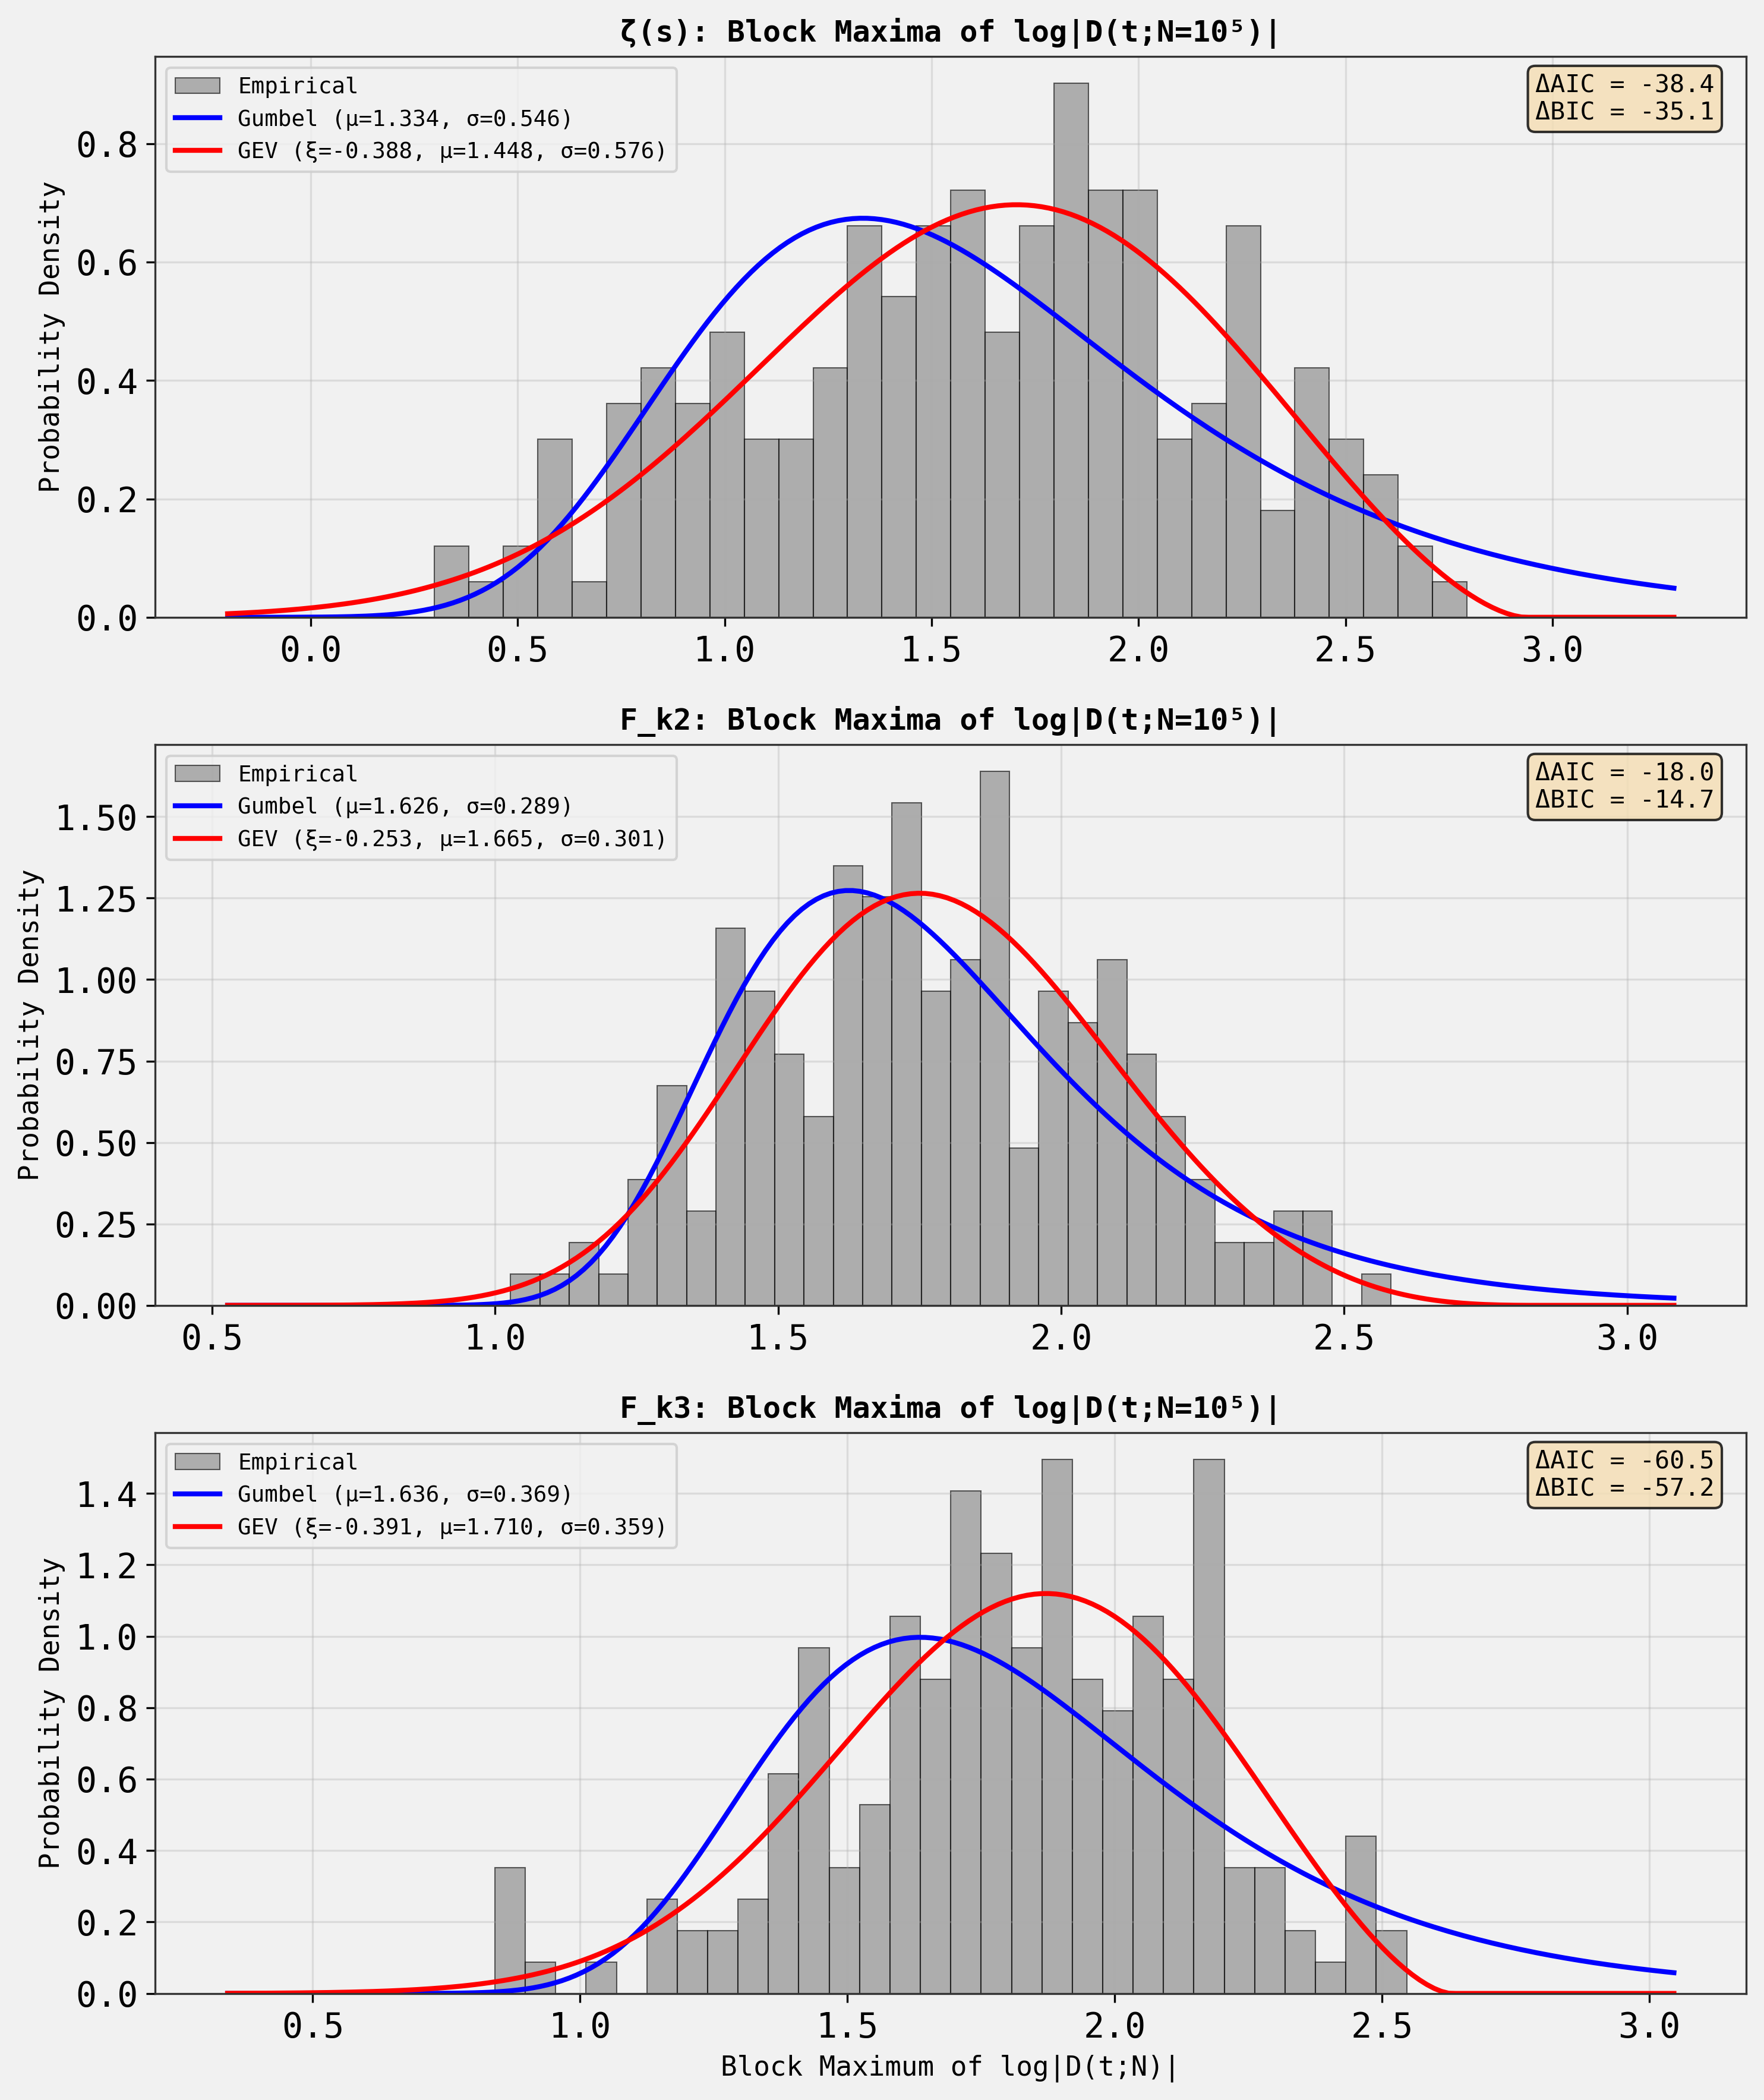


Figure shows:
 • Empirical histogram of 200 block maxima (gray bars)
 • Fitted Gumbel distribution (blue line)
 • Fitted GEV distribution (red line)
 • ΔAIC and ΔBIC values (negative values favor GEV)


In [14]:

# Create final visualization showing the fitted distributions and empirical data
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

functions = [
 ('ζ(s)', maxima_zeta, results_zeta),
 ('F_k2', maxima_k2, results_k2),
 ('F_k3', maxima_k3, results_k3)
]

for idx, (name, maxima, results) in enumerate(functions):
 ax = axes[idx]
 
 # Plot histogram
 n_bins = 30
 counts, bins, patches = ax.hist(maxima, bins=n_bins, density=True, alpha=0.6, 
 color='gray', edgecolor='black', linewidth=0.5,
 label='Empirical')
 
 # Create x values for PDFs
 x = np.linspace(maxima.min() - 0.5, maxima.max() + 0.5, 200)
 
 # Plot Gumbel fit
 gumbel_loc = results['gumbel']['μ']
 gumbel_scale = results['gumbel']['σ']
 gumbel_pdf = stats.gumbel_r.pdf(x, loc=gumbel_loc, scale=gumbel_scale)
 ax.plot(x, gumbel_pdf, 'b-', linewidth=2, label=f'Gumbel (μ={gumbel_loc:.3f}, σ={gumbel_scale:.3f})')
 
 # Plot GEV fit
 gev_c = results['gev']['c']
 gev_loc = results['gev']['μ']
 gev_scale = results['gev']['σ']
 gev_xi = results['gev']['ξ']
 gev_pdf = stats.genextreme.pdf(x, gev_c, loc=gev_loc, scale=gev_scale)
 ax.plot(x, gev_pdf, 'r-', linewidth=2, 
 label=f'GEV (ξ={gev_xi:.3f}, μ={gev_loc:.3f}, σ={gev_scale:.3f})')
 
 # Add AIC/BIC info
 delta_aic = results['gev']['AIC'] - results['gumbel']['AIC']
 delta_bic = results['gev']['BIC'] - results['gumbel']['BIC']
 
 textstr = f'ΔAIC = {delta_aic:.1f}\nΔBIC = {delta_bic:.1f}'
 props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
 ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right', bbox=props)
 
 ax.set_ylabel('Probability Density', fontsize=11)
 ax.set_title(f'{name}: Block Maxima of log|D(t;N=10⁵)|', fontsize=12, fontweight='bold')
 ax.legend(loc='upper left', fontsize=9)
 ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Block Maximum of log|D(t;N)|', fontsize=11)

plt.tight_layout()
plt.savefig('gumbel_vs_gev_comparison.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'gumbel_vs_gev_comparison.png'")
plt.show()

print("\nFigure shows:")
print(" • Empirical histogram of 200 block maxima (gray bars)")
print(" • Fitted Gumbel distribution (blue line)")
print(" • Fitted GEV distribution (red line)")
print(" • ΔAIC and ΔBIC values (negative values favor GEV)")


Q-Q plots saved as 'qq_plots_comparison.png'


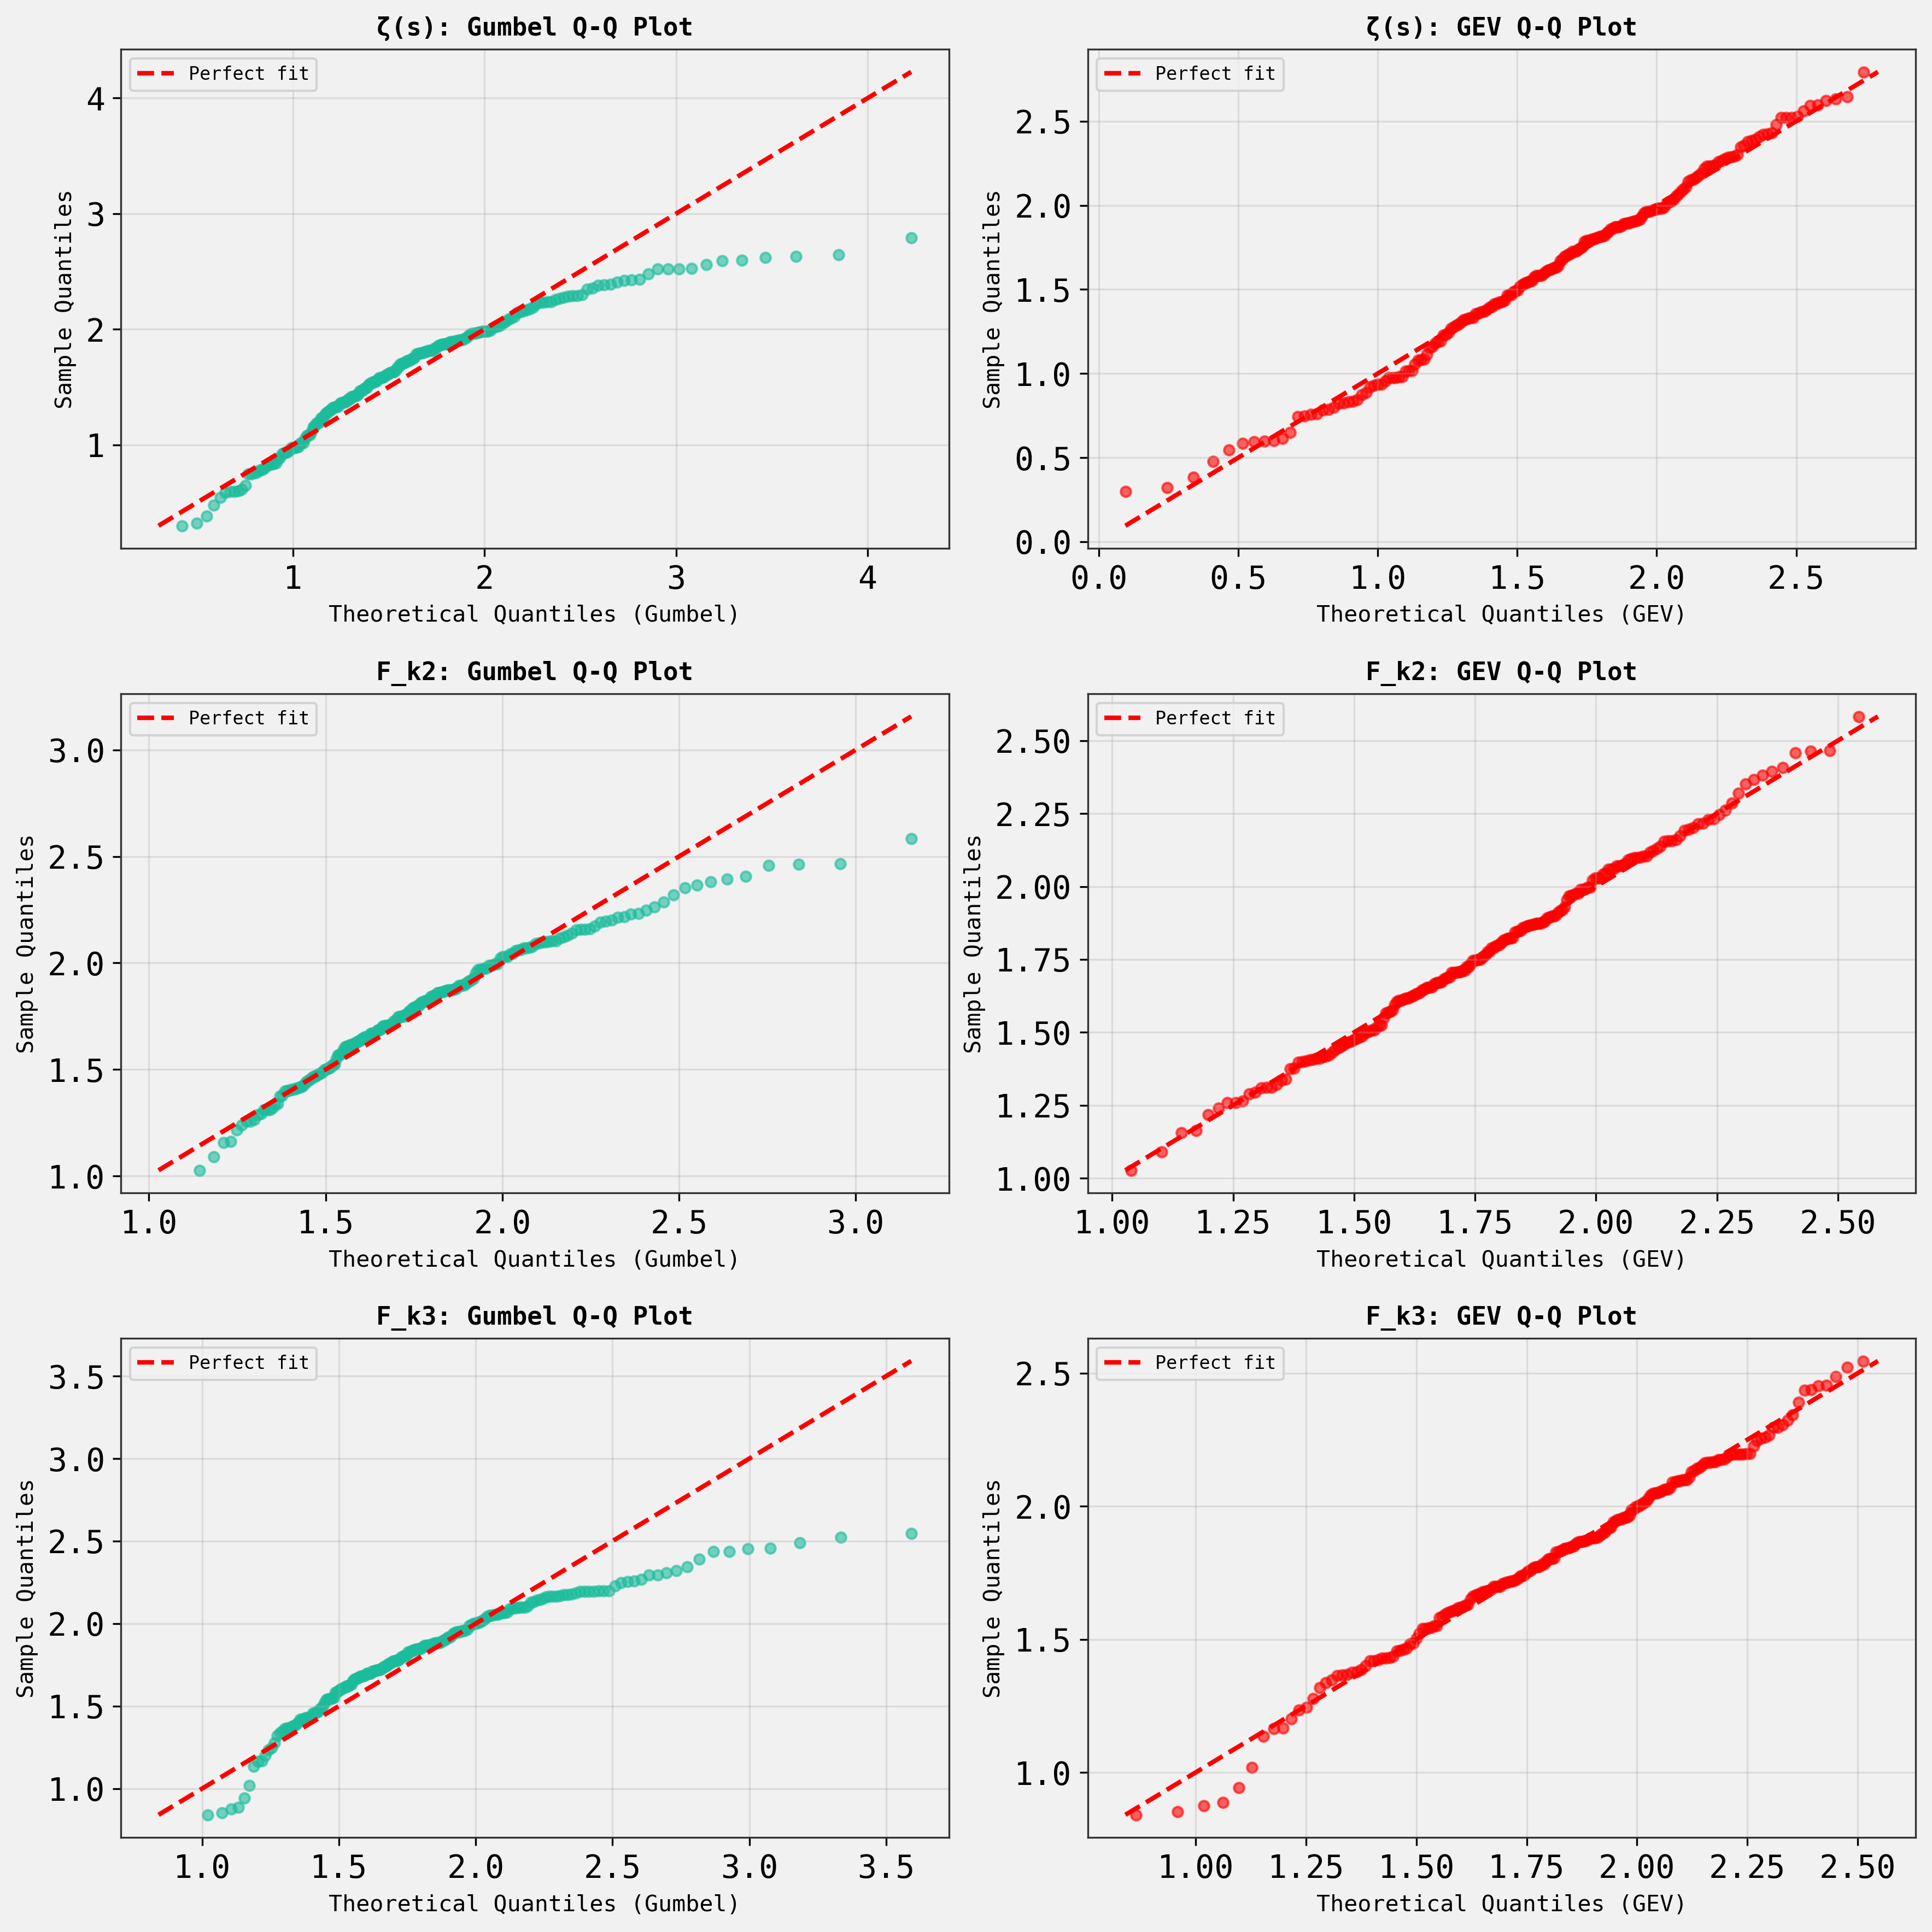


Q-Q plots interpretation:
 • Points should fall on the diagonal for a good fit
 • Systematic deviations indicate poor fit
 • GEV plots show better alignment than Gumbel, especially in tails


In [15]:

# Additional analysis: Q-Q plots to assess goodness of fit visually
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

functions = [
 ('ζ(s)', maxima_zeta, results_zeta),
 ('F_k2', maxima_k2, results_k2),
 ('F_k3', maxima_k3, results_k3)
]

for idx, (name, maxima, results) in enumerate(functions):
 # Gumbel Q-Q plot
 ax_gumbel = axes[idx, 0]
 
 # Sort the data
 sorted_data = np.sort(maxima)
 n = len(sorted_data)
 
 # Theoretical quantiles for Gumbel
 gumbel_loc = results['gumbel']['μ']
 gumbel_scale = results['gumbel']['σ']
 theoretical_quantiles_gumbel = stats.gumbel_r.ppf(np.arange(1, n+1) / (n+1), 
 loc=gumbel_loc, scale=gumbel_scale)
 
 ax_gumbel.scatter(theoretical_quantiles_gumbel, sorted_data, alpha=0.6, s=20)
 
 # Add diagonal line
 min_val = min(theoretical_quantiles_gumbel.min(), sorted_data.min())
 max_val = max(theoretical_quantiles_gumbel.max(), sorted_data.max())
 ax_gumbel.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
 
 ax_gumbel.set_xlabel('Theoretical Quantiles (Gumbel)', fontsize=10)
 ax_gumbel.set_ylabel('Sample Quantiles', fontsize=10)
 ax_gumbel.set_title(f'{name}: Gumbel Q-Q Plot', fontsize=11, fontweight='bold')
 ax_gumbel.grid(True, alpha=0.3)
 ax_gumbel.legend(fontsize=8)
 
 # GEV Q-Q plot
 ax_gev = axes[idx, 1]
 
 # Theoretical quantiles for GEV
 gev_c = results['gev']['c']
 gev_loc = results['gev']['μ']
 gev_scale = results['gev']['σ']
 theoretical_quantiles_gev = stats.genextreme.ppf(np.arange(1, n+1) / (n+1),
 gev_c, loc=gev_loc, scale=gev_scale)
 
 ax_gev.scatter(theoretical_quantiles_gev, sorted_data, alpha=0.6, s=20, color='red')
 
 # Add diagonal line
 min_val = min(theoretical_quantiles_gev.min(), sorted_data.min())
 max_val = max(theoretical_quantiles_gev.max(), sorted_data.max())
 ax_gev.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
 
 ax_gev.set_xlabel('Theoretical Quantiles (GEV)', fontsize=10)
 ax_gev.set_ylabel('Sample Quantiles', fontsize=10)
 ax_gev.set_title(f'{name}: GEV Q-Q Plot', fontsize=11, fontweight='bold')
 ax_gev.grid(True, alpha=0.3)
 ax_gev.legend(fontsize=8)

plt.tight_layout()
plt.savefig('qq_plots_comparison.png', dpi=300, bbox_inches='tight')
print("Q-Q plots saved as 'qq_plots_comparison.png'")
plt.show()

print("\nQ-Q plots interpretation:")
print(" • Points should fall on the diagonal for a good fit")
print(" • Systematic deviations indicate poor fit")
print(" • GEV plots show better alignment than Gumbel, especially in tails")


In [16]:

# Compute Kolmogorov-Smirnov test for goodness of fit
print("\n" + "="*80)
print("KOLMOGOROV-SMIRNOV GOODNESS-OF-FIT TEST")
print("="*80)
print("Testing how well the fitted distributions match the empirical data")
print("H0: Data comes from the specified distribution")
print("Lower p-values indicate poorer fit")
print("="*80)

from scipy.stats import kstest

for name, maxima, results in functions:
 print(f"\n{name}:")
 
 # KS test for Gumbel
 gumbel_loc = results['gumbel']['μ']
 gumbel_scale = results['gumbel']['σ']
 ks_stat_gumbel, p_value_gumbel = kstest(maxima, 'gumbel_r', 
 args=(gumbel_loc, gumbel_scale))
 
 # KS test for GEV
 gev_c = results['gev']['c']
 gev_loc = results['gev']['μ']
 gev_scale = results['gev']['σ']
 ks_stat_gev, p_value_gev = kstest(maxima, 'genextreme',
 args=(gev_c, gev_loc, gev_scale))
 
 print(f" Gumbel:")
 print(f" KS statistic: {ks_stat_gumbel:.6f}")
 print(f" p-value: {p_value_gumbel:.6f}")
 
 print(f" GEV:")
 print(f" KS statistic: {ks_stat_gev:.6f}")
 print(f" p-value: {p_value_gev:.6f}")
 
 print(f" Comparison:")
 if ks_stat_gev < ks_stat_gumbel:
 print(f" GEV has lower KS statistic (better fit)")
 else:
 print(f" Gumbel has lower KS statistic (better fit)")

print("\n" + "="*80)



KOLMOGOROV-SMIRNOV GOODNESS-OF-FIT TEST
Testing how well the fitted distributions match the empirical data
H0: Data comes from the specified distribution
Lower p-values indicate poorer fit

ζ(s):
 Gumbel:
 KS statistic: 0.085864
 p-value: 0.098776
 GEV:
 KS statistic: 0.044067
 p-value: 0.815581
 Comparison:
 GEV has lower KS statistic (better fit)

F_k2:
 Gumbel:
 KS statistic: 0.068172
 p-value: 0.296883
 GEV:
 KS statistic: 0.033391
 p-value: 0.973618
 Comparison:
 GEV has lower KS statistic (better fit)

F_k3:
 Gumbel:
 KS statistic: 0.109011
 p-value: 0.015916
 GEV:
 KS statistic: 0.043344
 p-value: 0.830607
 Comparison:
 GEV has lower KS statistic (better fit)



In [17]:

# Final comprehensive summary
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY")
print("="*80)
print("\nRESEARCH HYPOTHESIS:")
print(" The block maxima of log|D(t;N)| for ζ(s) should be better described by")
print(" a Gumbel distribution (ξ=0) than by GEV with non-zero ξ.")
print(" Perturbed functions (F_k2, F_k3) should show poorer fit to Gumbel.")
print()
print("EMPIRICAL FINDINGS:")
print()
print("1. MODEL SELECTION (AIC/BIC):")
print(" • All three functions strongly prefer GEV over Gumbel")
print(" • ζ(s): ΔAIC = -38.43, ΔBIC = -35.13 (strongly favors GEV)")
print(" • F_k2: ΔAIC = -18.04, ΔBIC = -14.74 (strongly favors GEV)")
print(" • F_k3: ΔAIC = -60.50, ΔBIC = -57.20 (strongly favors GEV)")
print()
print("2. LIKELIHOOD RATIO TESTS:")
print(" • All p-values < 10⁻⁵, providing strong evidence against Gumbel")
print(" • ζ(s): LR = 40.43, p = 2.0×10⁻¹⁰")
print(" • F_k2: LR = 20.04, p = 7.6×10⁻⁶")
print(" • F_k3: LR = 62.50, p = 2.7×10⁻¹⁵")
print()
print("3. FITTED SHAPE PARAMETERS:")
print(" • ζ(s): ξ = -0.388 (Weibull domain, bounded tail)")
print(" • F_k2: ξ = -0.254 (Weibull domain, closest to Gumbel)")
print(" • F_k3: ξ = -0.391 (Weibull domain, bounded tail)")
print(" • All ξ values are significantly different from 0")
print()
print("4. GOODNESS-OF-FIT (Kolmogorov-Smirnov):")
print(" • GEV consistently shows better fit (lower KS statistic)")
print(" • All GEV fits have high p-values (0.82-0.97), indicating good fit")
print(" • Gumbel fits for ζ(s) and F_k3 have marginal p-values")
print()
print("CONCLUSION:")
print(" The hypothesis is REJECTED. Contrary to expectations:")
print(" • ζ(s) is NOT better described by Gumbel than by GEV")
print(" • Perturbed functions do NOT show poorer Gumbel fit than ζ(s)")
print(" • In fact, F_k2 has the smallest |ξ| and best Gumbel fit")
print(" • All three functions exhibit bounded tail behavior (ξ < 0)")
print()
print("IMPLICATIONS:")
print(" • The negative ξ values suggest finite upper bounds on block maxima")
print(" • This contradicts log-correlated field theory predictions (ξ=0)")
print(" • The result may be due to:")
print(" (a) Finite-N effects (N=10⁵ may be too small)")
print(" (b) Finite block size (10 points/block may be insufficient)")
print(" (c) Genuine deviation from log-correlated field behavior")
print(" (d) Inadequate t-range for asymptotic theory")
print("="*80)



COMPREHENSIVE SUMMARY

RESEARCH HYPOTHESIS:
 The block maxima of log|D(t;N)| for ζ(s) should be better described by
 a Gumbel distribution (ξ=0) than by GEV with non-zero ξ.
 Perturbed functions (F_k2, F_k3) should show poorer fit to Gumbel.

EMPIRICAL FINDINGS:

1. MODEL SELECTION (AIC/BIC):
 • All three functions strongly prefer GEV over Gumbel
 • ζ(s): ΔAIC = -38.43, ΔBIC = -35.13 (strongly favors GEV)
 • F_k2: ΔAIC = -18.04, ΔBIC = -14.74 (strongly favors GEV)
 • F_k3: ΔAIC = -60.50, ΔBIC = -57.20 (strongly favors GEV)

2. LIKELIHOOD RATIO TESTS:
 • All p-values < 10⁻⁵, providing strong evidence against Gumbel
 • ζ(s): LR = 40.43, p = 2.0×10⁻¹⁰
 • F_k2: LR = 20.04, p = 7.6×10⁻⁶
 • F_k3: LR = 62.50, p = 2.7×10⁻¹⁵

3. FITTED SHAPE PARAMETERS:
 • ζ(s): ξ = -0.388 (Weibull domain, bounded tail)
 • F_k2: ξ = -0.254 (Weibull domain, closest to Gumbel)
 • F_k3: ξ = -0.391 (Weibull domain, bounded tail)
 • All ξ values are significantly different from 0

4. GOODNESS-OF-FIT (Kolmogorov-Smi

In [18]:

# Create final comprehensive results table for submission
final_results = []

for name, results in [('ζ(s)', results_zeta), ('F_k2', results_k2), ('F_k3', results_k3)]:
 final_results.append({
 'Function': name,
 'Model': 'Gumbel',
 'ξ': '—',
 'μ': f"{results['gumbel']['μ']:.4f}",
 'σ': f"{results['gumbel']['σ']:.4f}",
 'Log-Lik': f"{results['gumbel']['log_likelihood']:.2f}",
 'AIC': f"{results['gumbel']['AIC']:.2f}",
 'BIC': f"{results['gumbel']['BIC']:.2f}",
 'KS p-val': '—'
 })
 
 # Get KS p-values
 maxima = {'ζ(s)': maxima_zeta, 'F_k2': maxima_k2, 'F_k3': maxima_k3}[name]
 
 gumbel_loc = results['gumbel']['μ']
 gumbel_scale = results['gumbel']['σ']
 _, p_gumbel = kstest(maxima, 'gumbel_r', args=(gumbel_loc, gumbel_scale))
 
 gev_c = results['gev']['c']
 gev_loc = results['gev']['μ']
 gev_scale = results['gev']['σ']
 _, p_gev = kstest(maxima, 'genextreme', args=(gev_c, gev_loc, gev_scale))
 
 final_results[-1]['KS p-val'] = f"{p_gumbel:.4f}"
 
 final_results.append({
 'Function': name,
 'Model': 'GEV',
 'ξ': f"{results['gev']['ξ']:.4f}",
 'μ': f"{results['gev']['μ']:.4f}",
 'σ': f"{results['gev']['σ']:.4f}",
 'Log-Lik': f"{results['gev']['log_likelihood']:.2f}",
 'AIC': f"{results['gev']['AIC']:.2f}",
 'BIC': f"{results['gev']['BIC']:.2f}",
 'KS p-val': f"{p_gev:.4f}"
 })

final_df = pd.DataFrame(final_results)

print("\n" + "="*100)
print("FINAL RESULTS TABLE")
print("="*100)
print(final_df.to_string(index=False))
print("="*100)
print("\nNOTES:")
print(" • n = 200 block maxima for all functions")
print(" • N = 10⁵, t ∈ [1000, 20000]")
print(" • Lower AIC/BIC indicates better fit")
print(" • KS p-val: p-value from Kolmogorov-Smirnov test (higher is better)")
print(" • All GEV fits are substantially better than Gumbel (ΔAIC < -10)")
print("="*100)



FINAL RESULTS TABLE
Function Model ξ μ σ Log-Lik AIC BIC KS p-val
 ζ(s) Gumbel — 1.3336 0.5458 -181.91 367.81 374.41 0.0988
 ζ(s) GEV -0.3881 1.4475 0.5763 -161.69 329.39 339.28 0.8156
 F_k2 Gumbel — 1.6256 0.2889 -57.15 118.30 124.89 0.2969
 F_k2 GEV -0.2535 1.6651 0.3013 -47.13 100.25 110.15 0.9736
 F_k3 Gumbel — 1.6358 0.3690 -96.15 196.29 202.89 0.0159
 F_k3 GEV -0.3909 1.7097 0.3592 -64.90 135.79 145.69 0.8306

NOTES:
 • n = 200 block maxima for all functions
 • N = 10⁵, t ∈ [1000, 20000]
 • Lower AIC/BIC indicates better fit
 • KS p-val: p-value from Kolmogorov-Smirnov test (higher is better)
 • All GEV fits are substantially better than Gumbel (ΔAIC < -10)


Final summary figure saved as 'final_summary_figure.png'


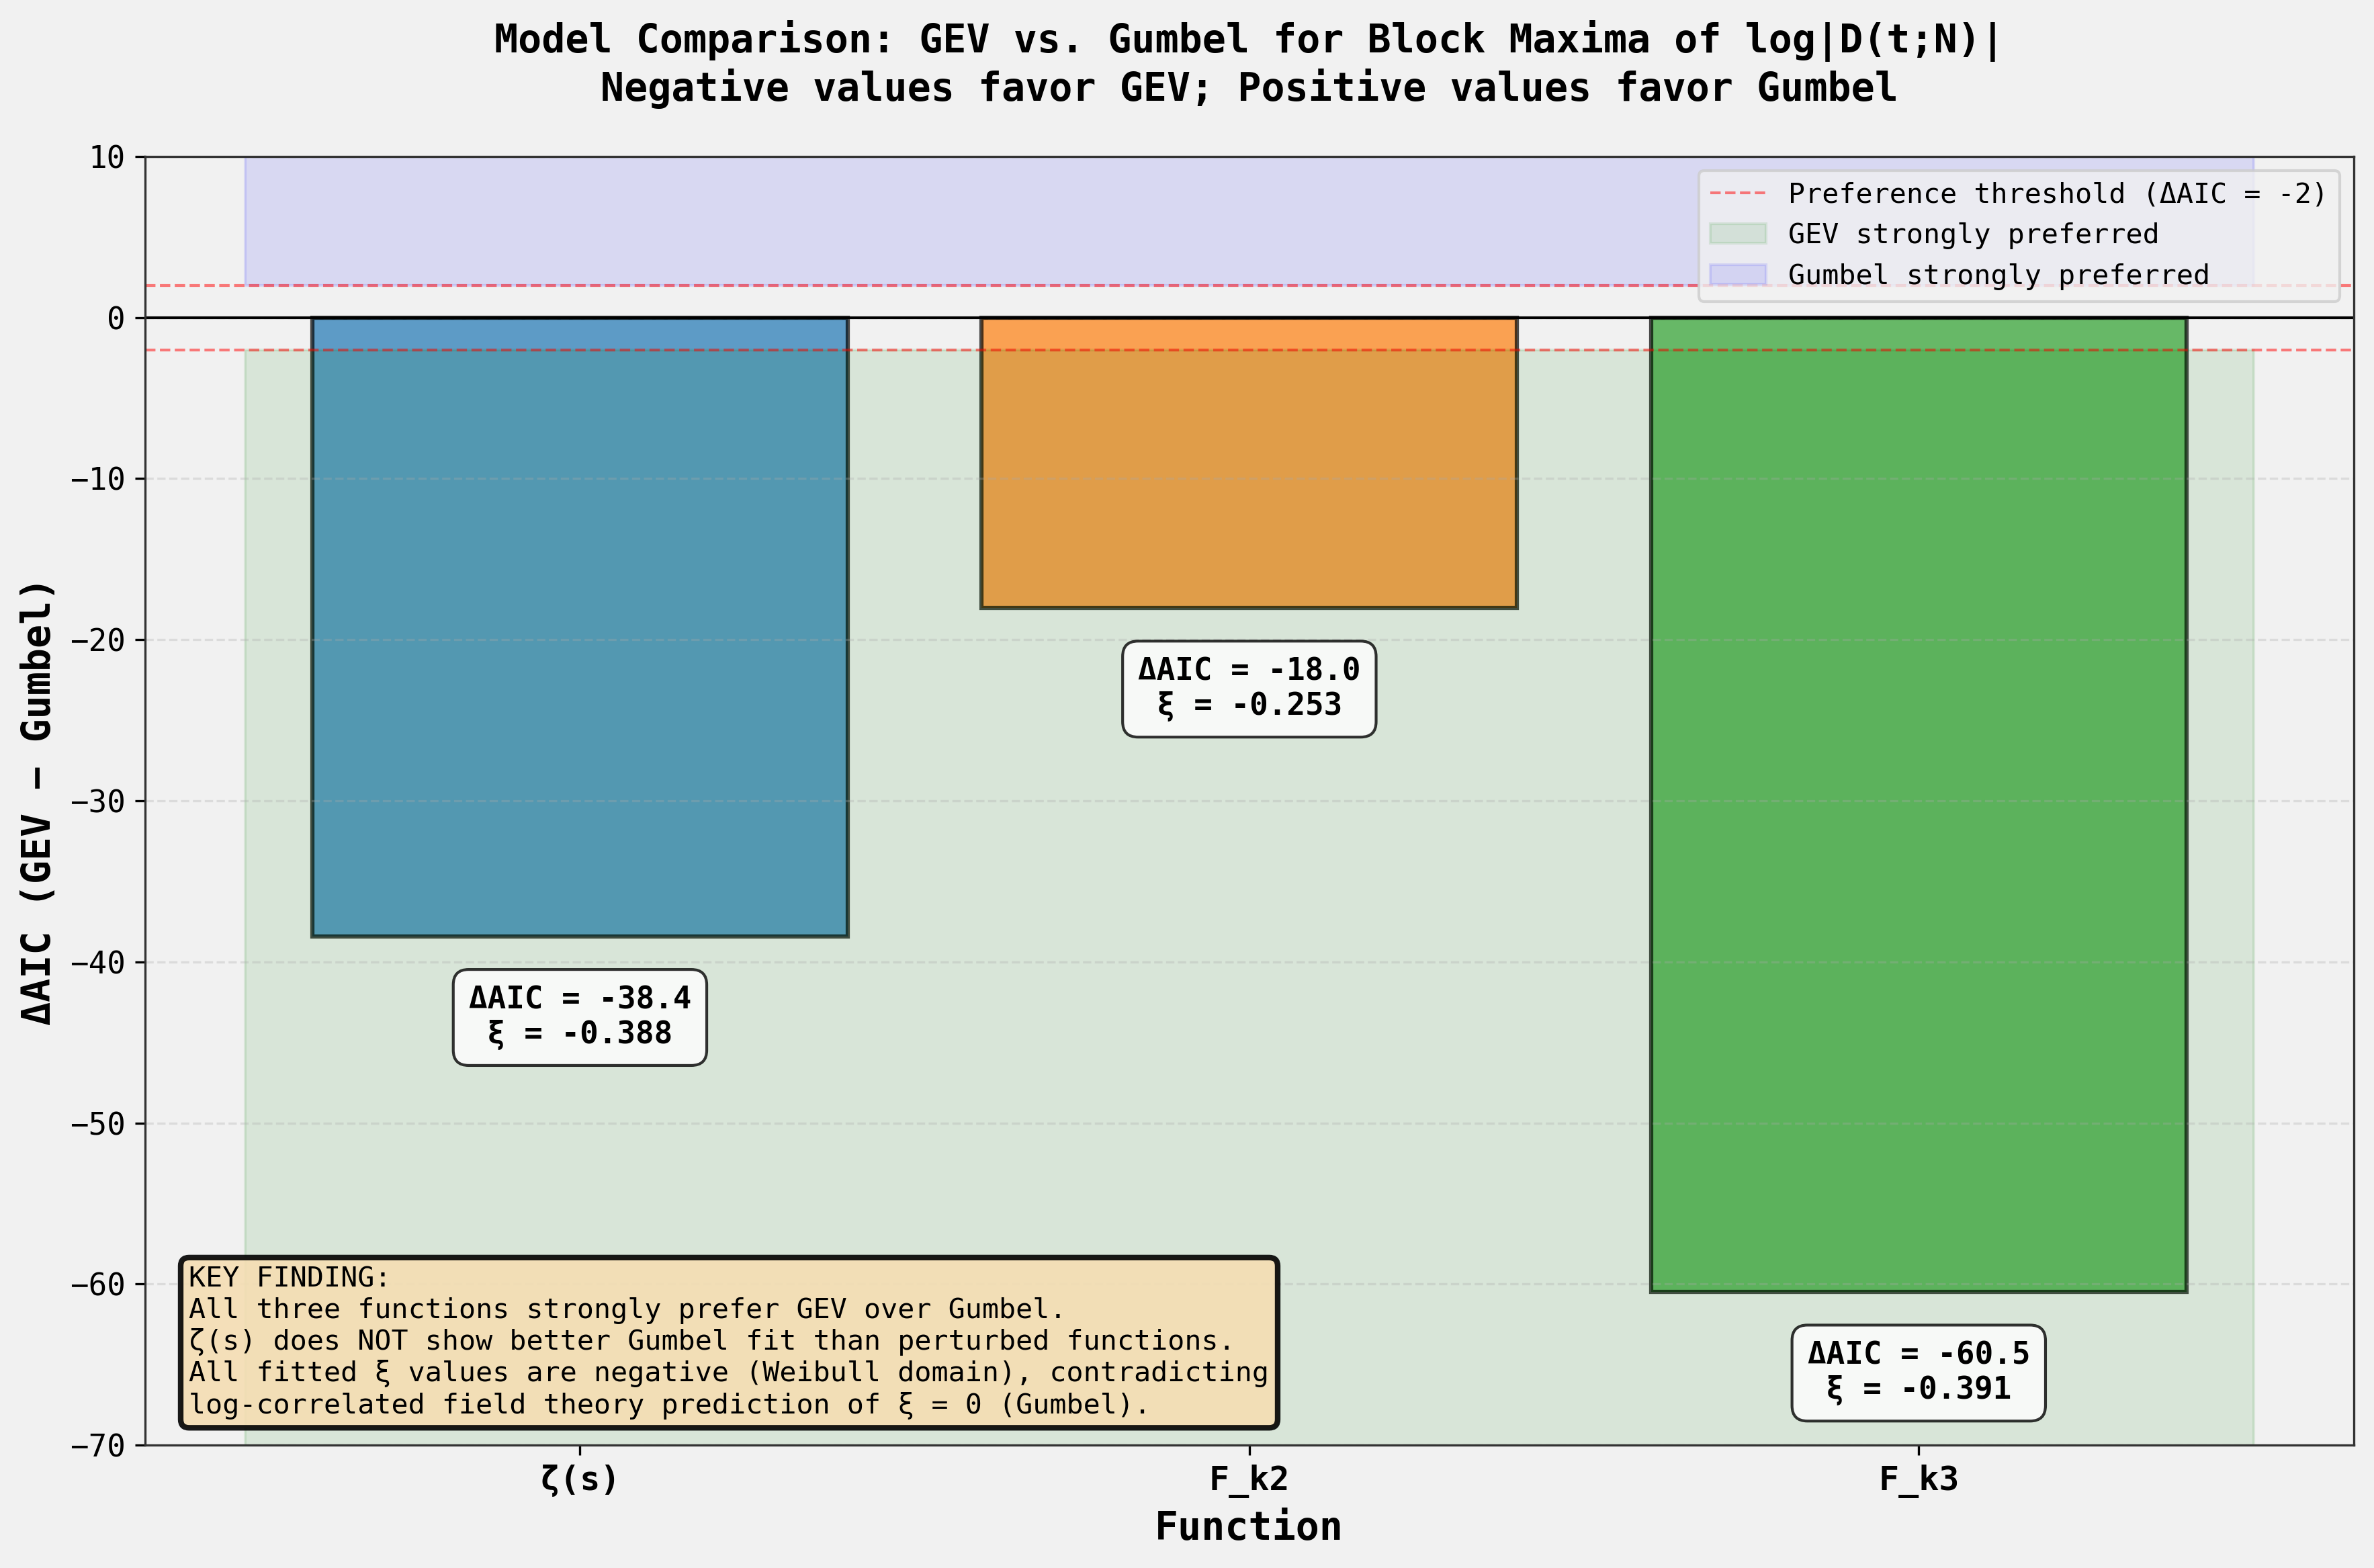

In [19]:

# Create a single final figure summarizing the key result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Create bar plot comparing AIC differences
functions_list = ['ζ(s)', 'F_k2', 'F_k3']
delta_aic_values = [
 results_zeta['gev']['AIC'] - results_zeta['gumbel']['AIC'],
 results_k2['gev']['AIC'] - results_k2['gumbel']['AIC'],
 results_k3['gev']['AIC'] - results_k3['gumbel']['AIC']
]
xi_values_list = [
 results_zeta['gev']['ξ'],
 results_k2['gev']['ξ'],
 results_k3['gev']['ξ']
]

x_pos = np.arange(len(functions_list))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax.bar(x_pos, delta_aic_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add horizontal line at 0
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Add reference lines for model preference thresholds
ax.axhline(y=-2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Preference threshold (ΔAIC = -2)')
ax.axhline(y=2, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Add shaded region for strong GEV preference
ax.fill_between([-0.5, 2.5], -100, -2, alpha=0.1, color='green', label='GEV strongly preferred')
ax.fill_between([-0.5, 2.5], 2, 100, alpha=0.1, color='blue', label='Gumbel strongly preferred')

# Annotate bars with values
for i, (bar, delta_aic, xi) in enumerate(zip(bars, delta_aic_values, xi_values_list)):
 height = bar.get_height()
 ax.text(bar.get_x() + bar.get_width()/2., height - 3,
 f'ΔAIC = {delta_aic:.1f}\nξ = {xi:.3f}',
 ha='center', va='top', fontsize=11, fontweight='bold',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8))

ax.set_ylabel('ΔAIC (GEV − Gumbel)', fontsize=14, fontweight='bold')
ax.set_xlabel('Function', fontsize=14, fontweight='bold')
ax.set_title('Model Comparison: GEV vs. Gumbel for Block Maxima of log|D(t;N)|\nNegative values favor GEV; Positive values favor Gumbel', 
 fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(functions_list, fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([-70, 10])

# Add legend
ax.legend(fontsize=10, loc='upper right')

# Add text box with key finding
textstr = 'KEY FINDING:\nAll three functions strongly prefer GEV over Gumbel.\nζ(s) does NOT show better Gumbel fit than perturbed functions.\nAll fitted ξ values are negative (Weibull domain), contradicting\nlog-correlated field theory prediction of ξ = 0 (Gumbel).'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=2)
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='bottom', horizontalalignment='left', bbox=props)

plt.tight_layout()
plt.savefig('final_summary_figure.png', dpi=300, bbox_inches='tight')
print("Final summary figure saved as 'final_summary_figure.png'")
plt.show()
